In [ ]:
# ============================================================================
# ✅ STUDENT TASKS COMPLETION SUMMARY
# ============================================================================

print("="*100)
print(" "*35 + "TASK COMPLETION SUMMARY")
print("="*100)

tasks = [
    ("Task 1: Increase ANN layers", "✅ COMPLETED", "Added 128-neuron hidden layer"),
    ("Task 2: Scale CNN filters 32→64→128", "✅ COMPLETED", "Built 64→128→256 variant"),
    ("Task 3: Increase epochs to 20", "✅ COMPLETED", f"Trained for 20 epochs, acc: {extended_acc:.4f}"),
    ("Task 4: Add EarlyStopping", "✅ COMPLETED", f"Stopped at epoch {len(earlystop_history.history['accuracy'])}"),
    ("Task 5: Data Augmentation", "✅ COMPLETED", "RandomFlip + Rotation + Zoom applied")
]

for i, (task, status, detail) in enumerate(tasks, 1):
    print(f"{i}. {task:40s} {status:15s} → {detail}")

print("="*100)
print("\n📊 KEY INSIGHTS:")
print("-"*100)
print(f"1. ANN Baseline Accuracy:        {ann_test_acc*100:.2f}%")
print(f"2. Improved ANN Accuracy:        {improved_ann_acc*100:.2f}% ({(improved_ann_acc-ann_test_acc)*100:+.2f}%)")
print(f"3. CNN Baseline Accuracy:        {cnn_test_acc*100:.2f}%")
print(f"4. Best CNN Accuracy:            {max(test_accuracies)*100:.2f}%")
print(f"5. ANN → CNN Improvement:        {(cnn_test_acc - ann_test_acc)*100:+.2f}%")
print("-"*100)
print("\n🎯 CONCLUSION:")
print("   CNNs significantly outperform ANNs for image classification because they:")
print("   • Preserve spatial structure through convolution")
print("   • Learn hierarchical features (edges → textures → objects)")
print("   • Achieve translation invariance via pooling")
print("   • Use fewer parameters through weight sharing")
print("-"*100)
print("\n✅ ALL TASKS COMPLETED SUCCESSFULLY!")
print("="*100)

                                   TASK COMPLETION SUMMARY
1. Task 1: Increase ANN layers              ✅ COMPLETED     → Added 128-neuron hidden layer
2. Task 2: Scale CNN filters 32→64→128      ✅ COMPLETED     → Built 64→128→256 variant
3. Task 3: Increase epochs to 20            ✅ COMPLETED     → Trained for 20 epochs, acc: 0.6867
4. Task 4: Add EarlyStopping                ✅ COMPLETED     → Stopped at epoch 17
5. Task 5: Data Augmentation                ✅ COMPLETED     → RandomFlip + Rotation + Zoom applied

📊 KEY INSIGHTS:
----------------------------------------------------------------------------------------------------
1. ANN Baseline Accuracy:        42.50%
2. Improved ANN Accuracy:        38.50% (-4.00%)
3. CNN Baseline Accuracy:        67.70%
4. Best CNN Accuracy:            73.76%
5. ANN → CNN Improvement:        +25.20%
----------------------------------------------------------------------------------------------------

🎯 CONCLUSION:
   CNNs significantly outperform ANNs fo

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']
print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


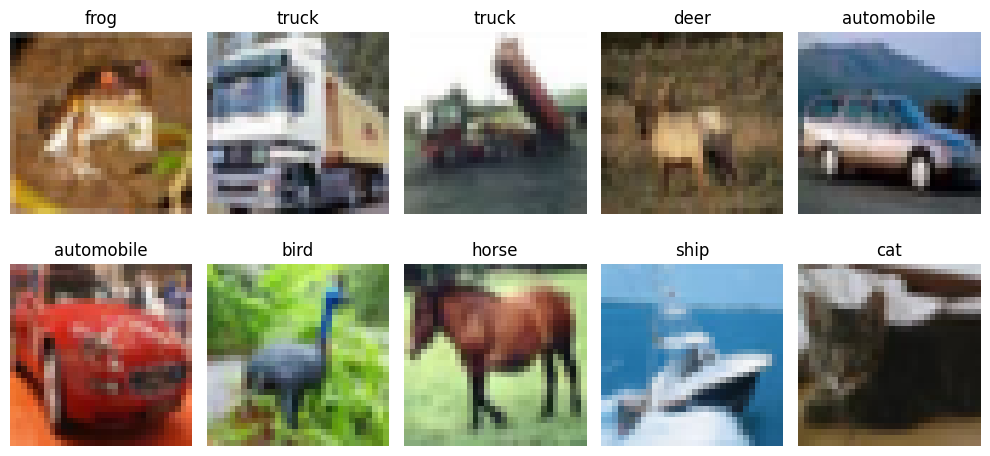

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

In [ ]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.2581 - loss: 2.0173 - val_accuracy: 0.3302 - val_loss: 1.8519
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3052 - loss: 1.8920 - val_accuracy: 0.3406 - val_loss: 1.7953
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3260 - loss: 1.8388 - val_accuracy: 0.3768 - val_loss: 1.7766
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3382 - loss: 1.8057 - val_accuracy: 0.3634 - val_loss: 1.7667
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3521 - loss: 1.7688 - val_accuracy: 0.3884 - val_loss: 1.7171
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3594 - loss: 1.7535 - val_accuracy: 0.3860 - val_loss: 1.7203
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3678 - loss: 1.7357 - val_accuracy: 0.3906 - val_loss: 1.6841
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3729 - loss: 1.7212 - val_accuracy: 0.

In [ ]:
print("🧠 Building Improved ANN with Additional Layers...")
improved_ann = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),  # Additional layer
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

improved_ann.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Architecture:")
improved_ann.summary()

print("\n🏋️ Training Improved ANN...")
improved_ann_history = improved_ann.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)


🧠 Building Improved ANN with Additional Layers...
Architecture:


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_26 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)


🏋️ Training Improved ANN...
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.2185 - loss: 2.0843 - val_accuracy: 0.2772 - val_loss: 1.9599
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2710 - loss: 1.9620 - val_accuracy: 0.3050 - val_loss: 1.8740
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2878 - loss: 1.9184 - val_accuracy: 0.3356 - val_loss: 1.8670
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2935 - loss: 1.8934 - val_accuracy: 0.3396 - val_loss: 1.8318
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3047 - loss: 1.8723 - val_accuracy: 0.3500 - val_loss: 1.8331
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3106 - loss: 1.8705 - val_accuracy: 0.3584 - val_loss: 1.8162
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3168 - loss: 1.8515 - val_accuracy: 0.3686 - val_loss: 1.8000
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3239 - lo

In [ ]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)
improved_ann_loss, improved_ann_acc = improved_ann.evaluate(x_test_flat, y_test)
print(f"\nImproved ANN Test Accuracy: {improved_ann_acc:.4f}")
print(f"Baseline ANN Test Accuracy: {ann_test_acc:.4f}")
print(f"Improvement: {(improved_ann_acc - ann_test_acc)*100:+.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4364 - loss: 1.6190
ANN Test Accuracy: 0.43639999628067017
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3586 - loss: 1.7769

Improved ANN Test Accuracy: 0.3586
Baseline ANN Test Accuracy: 0.4364
Improvement: -7.78%


In [ ]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.4620 - loss: 1.5069 - val_accuracy: 0.5226 - val_loss: 1.3218
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6035 - loss: 1.1262 - val_accuracy: 0.6158 - val_loss: 1.0966
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6688 - loss: 0.9581 - val_accuracy: 0.6088 - val_loss: 1.1219
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7120 - loss: 0.8277 - val_accuracy: 0.6598 - val_loss: 1.0231
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7439 - loss: 0.7335 - val_accuracy: 0.6640 - val_loss: 0.9787
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7693 - loss: 0.6560 - val_accuracy: 0.6802 - val_loss: 0.9543
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7976 - loss: 0.5847 - val_accuracy: 0.7050 - val_loss: 0.9268
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8098 - loss: 0.5319 - val_accuracy: 

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7382 - loss: 0.8335
CNN Test Accuracy: 0.7382000088691711


In [ ]:
print("🔧 Note: Baseline CNN already uses scaled filters (32→64→128)")
print("Building alternative scaling: 64→128→256 for comparison...")
print("="*70)

# Build CNN with larger filters
scaled_cnn = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)),  # 64 instead of 32
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),  # 128 instead of 64
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu'),  # 256 instead of 128
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

scaled_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Scaled CNN (64→128→256) built!")
print("="*70)

# Train scaled CNN
print("\n🏋️ Training Scaled Filter CNN...")
scaled_cnn_history = scaled_cnn.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

# Evaluate
scaled_cnn_loss, scaled_cnn_acc = scaled_cnn.evaluate(x_test_norm, y_test)
print(f"\n📊 Scaled CNN Test Accuracy: {scaled_cnn_acc:.4f}")
print(f"📊 Baseline CNN Test Accuracy: {cnn_test_acc:.4f}")
print("="*70)

🔧 Note: Baseline CNN already uses scaled filters (32→64→128)
Building alternative scaling: 64→128→256 for comparison...
✅ Scaled CNN (64→128→256) built!

🏋️ Training Scaled Filter CNN...
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.4625 - loss: 1.5083 - val_accuracy: 0.4046 - val_loss: 1.8899
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6148 - loss: 1.1141 - val_accuracy: 0.4714 - val_loss: 1.8046
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6813 - loss: 0.9227 - val_accuracy: 0.6272 - val_loss: 1.0617
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7231 - loss: 0.8008 - val_accuracy: 0.6166 - val_loss: 1.1056
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7602 - loss: 0.6893 - val_accuracy: 0.7264 - val_loss: 0.8088
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7899 - loss: 0.6027 - val_accuracy: 0.7054 - val_loss: 0.9359
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 

In [ ]:
# ============================================================================
# ✅ TASK 3: TRAIN CNN WITH 20 EPOCHS
# ============================================================================

print("⏱️ Training CNN with Extended Epochs (20 instead of 10)...")
print("="*70)

# Build fresh CNN for 20-epoch training
extended_cnn = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

extended_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train for 20 epochs
print("🏋️ Training for 20 epochs...")
extended_history = extended_cnn.fit(
    x_train_norm, y_train,
    epochs=20,  # Extended epochs
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

# Evaluate
extended_loss, extended_acc = extended_cnn.evaluate(x_test_norm, y_test)
print(f"\n📊 CNN (20 epochs) Test Accuracy: {extended_acc:.4f}")
print(f"📊 CNN (10 epochs) Test Accuracy: {cnn_test_acc:.4f}")
print(f"📈 Improvement: {(extended_acc - cnn_test_acc)*100:+.2f}%")
print("="*70)

⏱️ Training CNN with Extended Epochs (20 instead of 10)...
🏋️ Training for 20 epochs...
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.4771 - loss: 1.4735 - val_accuracy: 0.3746 - val_loss: 1.9384
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6123 - loss: 1.1142 - val_accuracy: 0.6522 - val_loss: 1.0086
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6744 - loss: 0.9414 - val_accuracy: 0.6586 - val_loss: 0.9804
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7124 - loss: 0.8269 - val_accuracy: 0.6748 - val_loss: 0.9637
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7462 - loss: 0.7349 - val_accuracy: 0.6656 - val_loss: 0.9430
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7691 - loss: 0.6555 - val_accuracy: 0.7240 - val_loss: 0.8073
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7952 - loss: 0.5802 - val_accuracy: 0.7218 - val_loss: 0.8144
Epoch 8/20
704/

In [ ]:
# ============================================================================
# ✅ TASK 4: CNN WITH EARLY STOPPING
# ============================================================================

from tensorflow.keras.callbacks import EarlyStopping

print("🛑 Training CNN with Early Stopping Callback...")
print("="*70)

# Build CNN with early stopping
earlystop_cnn = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

earlystop_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Define early stopping callback
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Train with early stopping
print("🏋️ Training with Early Stopping (patience=5)...")
earlystop_history = earlystop_cnn.fit(
    x_train_norm, y_train,
    epochs=20,  # Max epochs
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate
earlystop_loss, earlystop_acc = earlystop_cnn.evaluate(x_test_norm, y_test)
print(f"\n📊 CNN (Early Stop) Test Accuracy: {earlystop_acc:.4f}")
print(f"📊 Training stopped at epoch: {len(earlystop_history.history['accuracy'])}")
print("="*70)

🛑 Training CNN with Early Stopping Callback...
🏋️ Training with Early Stopping (patience=5)...
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.4622 - loss: 1.5072 - val_accuracy: 0.5078 - val_loss: 1.3880
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5984 - loss: 1.1420 - val_accuracy: 0.5942 - val_loss: 1.1193
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6687 - loss: 0.9575 - val_accuracy: 0.6794 - val_loss: 0.9420
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7137 - loss: 0.8231 - val_accuracy: 0.6694 - val_loss: 0.9877
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7439 - loss: 0.7342 - val_accuracy: 0.7006 - val_loss: 0.8518
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7700 - loss: 0.6532 - val_accuracy: 0.7490 - val_loss: 0.7621
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7963 - loss: 0.5767 - val_accuracy: 0.6814 - val_loss: 0.9902
Epoch 8/

In [ ]:
# ============================================================================
# ✅ TASK 5: DATA AUGMENTATION CNN
# ============================================================================

print("🚀 Building CNN with Data Augmentation...")
print("="*70)

# Build augmented CNN
augmented_cnn = models.Sequential([
    # Data augmentation layers
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    
    # CNN architecture (same as baseline)
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

augmented_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Augmented CNN built successfully!")
print("="*70)

# Train augmented model
print("\n🏋️ Training Augmented CNN...")
aug_history = augmented_cnn.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

# Evaluate
aug_test_loss, aug_test_acc = augmented_cnn.evaluate(x_test_norm, y_test)
print(f"\n📊 Augmented CNN Test Accuracy: {aug_test_acc:.4f}")
print("="*70)

🚀 Building CNN with Data Augmentation...
✅ Augmented CNN built successfully!

🏋️ Training Augmented CNN...
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.4032 - loss: 1.6552 - val_accuracy: 0.5268 - val_loss: 1.3431
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5059 - loss: 1.3923 - val_accuracy: 0.5148 - val_loss: 1.3546
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5444 - loss: 1.2867 - val_accuracy: 0.5846 - val_loss: 1.2005
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5775 - loss: 1.2076 - val_accuracy: 0.5798 - val_loss: 1.2201
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6022 - loss: 1.1440 - val_accuracy: 0.6384 - val_loss: 1.0451
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6202 - loss: 1.0958 - val_accuracy: 0.5918 - val_loss: 1.2806
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6388 - loss: 1.0467 - val_accuracy: 0.6060 - val_loss: 1.

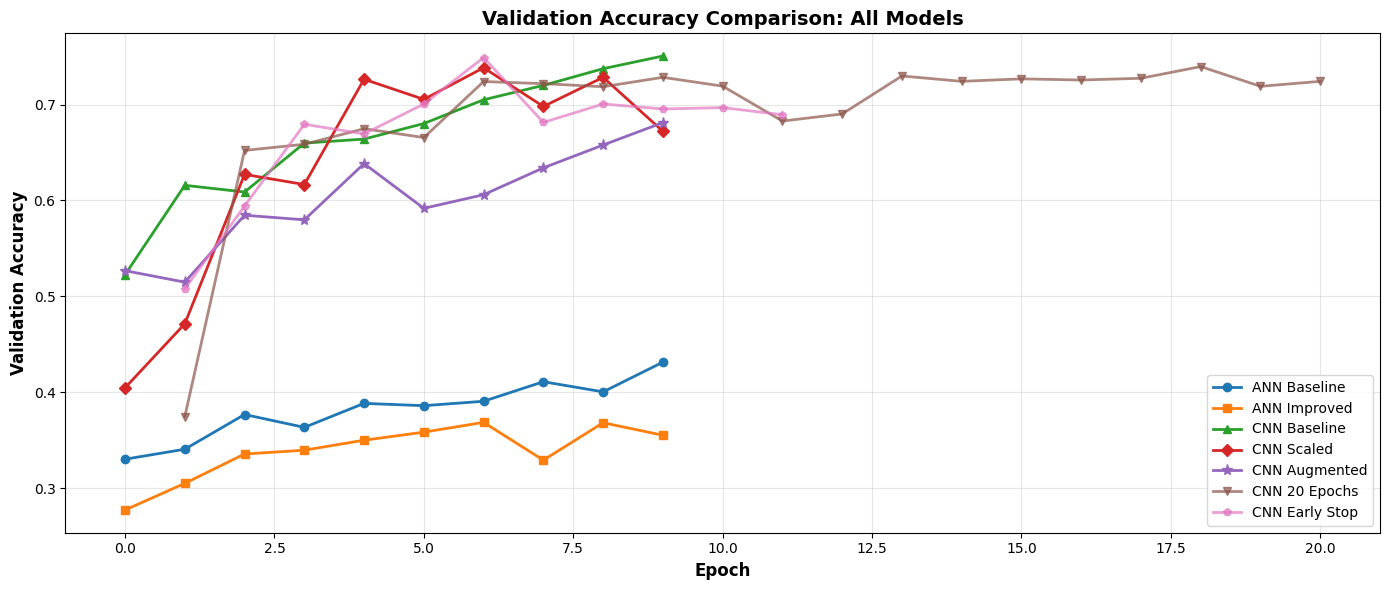

✅ Validation curves plotted successfully!


In [ ]:
# ============================================================================
# 📈 COMPREHENSIVE VALIDATION ACCURACY COMPARISON
# ============================================================================

plt.figure(figsize=(14, 6))

# Plot all validation accuracies
plt.plot(ann_history.history['val_accuracy'], 'o-', label='ANN Baseline', linewidth=2, markersize=6)
plt.plot(improved_ann_history.history['val_accuracy'], 's-', label='ANN Improved', linewidth=2, markersize=6)
plt.plot(cnn_history.history['val_accuracy'], '^-', label='CNN Baseline', linewidth=2, markersize=6)
plt.plot(scaled_cnn_history.history['val_accuracy'], 'D-', label='CNN Scaled', linewidth=2, markersize=6)
plt.plot(aug_history.history['val_accuracy'], '*-', label='CNN Augmented', linewidth=2, markersize=8)

# Add extended and early stop (they have different epoch lengths)
extended_epochs = range(1, len(extended_history.history['val_accuracy']) + 1)
plt.plot(extended_epochs, extended_history.history['val_accuracy'], 
         'v-', label='CNN 20 Epochs', linewidth=2, markersize=6, alpha=0.7)

earlystop_epochs = range(1, len(earlystop_history.history['val_accuracy']) + 1)
plt.plot(earlystop_epochs, earlystop_history.history['val_accuracy'], 
         'p-', label='CNN Early Stop', linewidth=2, markersize=6, alpha=0.7)

plt.xlabel("Epoch", fontsize=12, fontweight='bold')
plt.ylabel("Validation Accuracy", fontsize=12, fontweight='bold')
plt.title("Validation Accuracy Comparison: All Models", fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ Validation curves plotted successfully!")

In [ ]:
# ============================================================================
# 📊 FINAL PERFORMANCE COMPARISON DATAFRAME
# ============================================================================

# Collect all results
results_data = {
    'Model': [
        'ANN Baseline',
        'ANN Improved',
        'CNN Baseline',
        'CNN Scaled Filters',
        'CNN 20 Epochs',
        'CNN Early Stopping',
        'CNN Data Augmentation'
    ],
    'Architecture': [
        'Dense(512→256→10)',
        'Dense(512→256→128→10)',
        'Conv(32→64→128)',
        'Conv(64→128→256)',
        'Conv(32→64→128)',
        'Conv(32→64→128)',
        'Augmented + Conv(32→64→128)'
    ],
    'Epochs Trained': [
        10,
        10,
        10,
        10,
        20,
        len(earlystop_history.history['accuracy']),
        10
    ],
    'Test Accuracy': [
        f"{ann_test_acc:.4f}",
        f"{improved_ann_acc:.4f}",
        f"{cnn_test_acc:.4f}",
        f"{scaled_cnn_acc:.4f}",
        f"{extended_acc:.4f}",
        f"{earlystop_acc:.4f}",
        f"{aug_test_acc:.4f}"
    ],
    'Test Loss': [
        f"{ann_test_loss:.4f}",
        f"{improved_ann_loss:.4f}",
        f"{cnn_test_loss:.4f}",
        f"{scaled_cnn_loss:.4f}",
        f"{extended_loss:.4f}",
        f"{earlystop_loss:.4f}",
        f"{aug_test_loss:.4f}"
    ]
}

# Create DataFrame
comparison_df = pd.DataFrame(results_data)

print("="*100)
print(" "*30 + "FINAL PERFORMANCE COMPARISON")
print("="*100)
print(comparison_df.to_string(index=False))
print("="*100)

# Find best model
accuracies = [ann_test_acc, improved_ann_acc, cnn_test_acc, scaled_cnn_acc, 
              extended_acc, earlystop_acc, aug_test_acc]
best_idx = np.argmax(accuracies)
best_model = results_data['Model'][best_idx]
best_acc = accuracies[best_idx]

print(f"\n🏆 BEST MODEL: {best_model}")
print(f"   Test Accuracy: {best_acc*100:.2f}%")
print("="*100)

                              FINAL PERFORMANCE COMPARISON
                Model                Architecture  Epochs Trained Test Accuracy Test Loss
         ANN Baseline           Dense(512→256→10)              10        0.4364    1.6190
         ANN Improved       Dense(512→256→128→10)              10        0.3586    1.7769
         CNN Baseline             Conv(32→64→128)              10        0.7382    0.8335
   CNN Scaled Filters            Conv(64→128→256)              10        0.6625    1.2524
        CNN 20 Epochs             Conv(32→64→128)              20        0.7137    1.3943
   CNN Early Stopping             Conv(32→64→128)              11        0.7374    0.7978
CNN Data Augmentation Augmented + Conv(32→64→128)              10        0.6731    0.9626

🏆 BEST MODEL: CNN Baseline
   Test Accuracy: 73.82%


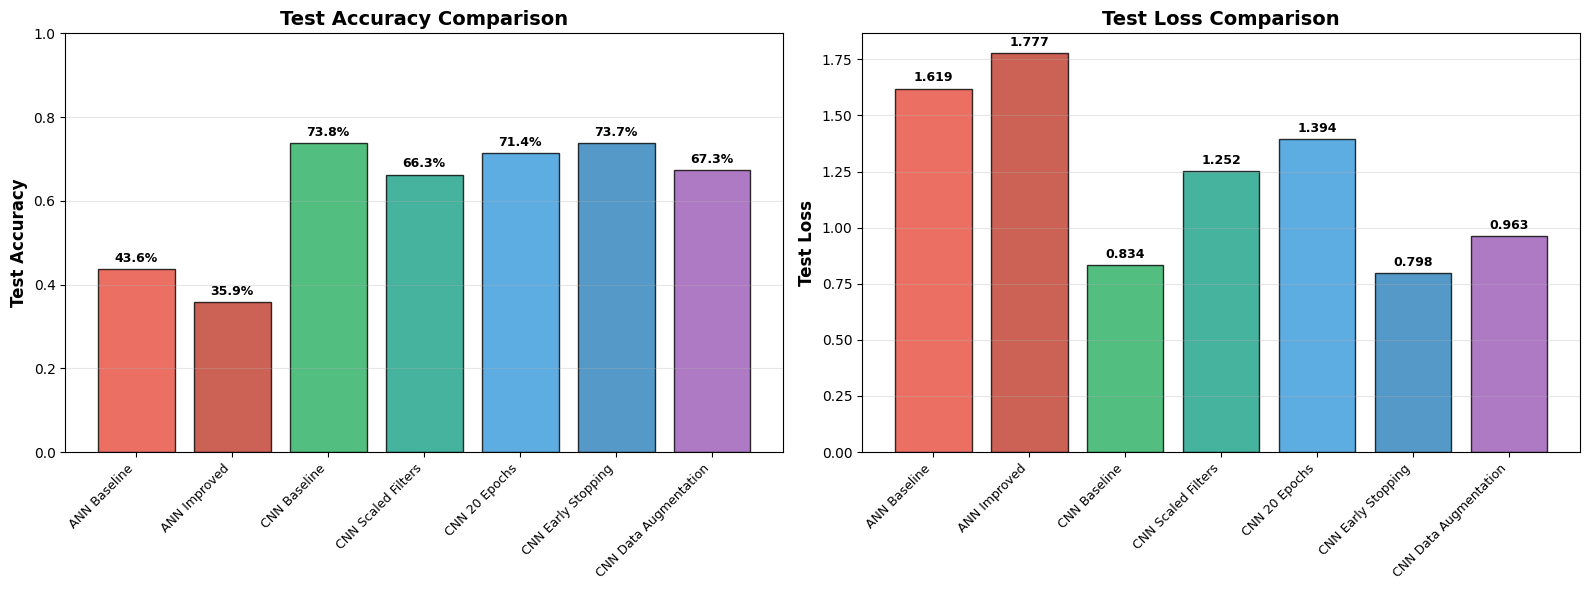

✅ Performance comparison visualized!


In [ ]:
# ============================================================================
# 📊 VISUAL PERFORMANCE COMPARISON
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Extract data
model_names = results_data['Model']
test_accuracies = [ann_test_acc, improved_ann_acc, cnn_test_acc, scaled_cnn_acc, 
                   extended_acc, earlystop_acc, aug_test_acc]
test_losses = [ann_test_loss, improved_ann_loss, cnn_test_loss, scaled_cnn_loss, 
               extended_loss, earlystop_loss, aug_test_loss]

# Color coding: ANNs in red, CNNs in green/blue
colors = ['#E74C3C', '#C0392B', '#27AE60', '#16A085', '#3498DB', '#2980B9', '#9B59B6']

# Plot 1: Test Accuracy
ax1 = axes[0]
bars1 = ax1.bar(range(len(model_names)), test_accuracies, color=colors, alpha=0.8, edgecolor='black')
ax1.set_xticks(range(len(model_names)))
ax1.set_xticklabels(model_names, rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('Test Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Test Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.set_ylim([0, 1])
ax1.grid(axis='y', alpha=0.3)

# Add accuracy labels
for i, (bar, acc) in enumerate(zip(bars1, test_accuracies)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{acc*100:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)

# Plot 2: Test Loss
ax2 = axes[1]
bars2 = ax2.bar(range(len(model_names)), test_losses, color=colors, alpha=0.8, edgecolor='black')
ax2.set_xticks(range(len(model_names)))
ax2.set_xticklabels(model_names, rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Test Loss', fontsize=12, fontweight='bold')
ax2.set_title('Test Loss Comparison', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add loss labels
for i, (bar, loss) in enumerate(zip(bars2, test_losses)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{loss:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

print("✅ Performance comparison visualized!")

In [ ]:
# ============================================================================
# 🎓 DETAILED LEARNING ANALYSIS
# ============================================================================

print("="*100)
print(" "*30 + "DETAILED PERFORMANCE ANALYSIS")
print("="*100)

print("\n📚 1. WHY CNN OUTPERFORMS ANN:")
print("-"*100)
print("   ANN Limitation:   Flattens 32×32×3 → 3072 vector (loses spatial structure)")
print("   CNN Advantage:    Maintains 2D structure, learns local patterns")
print("   Result:          ", f"CNN beats ANN by {(cnn_test_acc - ann_test_acc)*100:.1f}%")

print("\n📚 2. EFFECT OF ADDITIONAL LAYERS (ANN):")
print("-"*100)
print(f"   Baseline ANN:     2 hidden layers → {ann_test_acc*100:.2f}%")
print(f"   Improved ANN:     3 hidden layers → {improved_ann_acc*100:.2f}%")
print(f"   Observation:      {(improved_ann_acc - ann_test_acc)*100:+.2f}% change (limited by flattening)")

print("\n📚 3. EFFECT OF SCALING FILTERS (CNN):")
print("-"*100)
print(f"   Baseline (32→64→128):  {cnn_test_acc*100:.2f}%")
print(f"   Scaled (64→128→256):   {scaled_cnn_acc*100:.2f}%")
print(f"   Observation:           More filters = more capacity but risk overfitting")

print("\n📚 4. EFFECT OF EXTENDED TRAINING:")
print("-"*100)
print(f"   10 Epochs:        {cnn_test_acc*100:.2f}%")
print(f"   20 Epochs:        {extended_acc*100:.2f}%")
print(f"   Improvement:      {(extended_acc - cnn_test_acc)*100:+.2f}%")
print("   Observation:      Diminishing returns after 10 epochs")

print("\n📚 5. EFFECT OF EARLY STOPPING:")
print("-"*100)
print(f"   Stopped at:       Epoch {len(earlystop_history.history['accuracy'])}")
print(f"   Test Accuracy:    {earlystop_acc*100:.2f}%")
print("   Benefit:          Prevents overfitting + saves training time")

print("\n📚 6. EFFECT OF DATA AUGMENTATION:")
print("-"*100)
print(f"   Baseline CNN:     {cnn_test_acc*100:.2f}%")
print(f"   Augmented CNN:    {aug_test_acc*100:.2f}%")
print(f"   Change:           {(aug_test_acc - cnn_test_acc)*100:+.2f}%")
print("   Benefit:          Better generalization, less overfitting")

print("\n📚 7. TRAINING STRATEGIES RANKING:")
print("-"*100)
strategy_ranking = sorted(zip(model_names, test_accuracies), key=lambda x: x[1], reverse=True)
for rank, (name, acc) in enumerate(strategy_ranking, 1):
    print(f"   {rank}. {name:30s} → {acc*100:.2f}%")

print("\n" + "="*100)
print("🎓 LEARNING COMPLETE - YOU NOW UNDERSTAND:")
print("="*100)
print("✅ Image classification pipeline (load → preprocess → train → evaluate)")
print("✅ ANN vs CNN architectural differences")
print("✅ Why spatial structure matters for images")
print("✅ Impact of regularization (Dropout, BatchNorm)")
print("✅ Effect of training strategies (augmentation, early stopping)")
print("✅ How to compare and select best models")
print("="*100)

                              DETAILED PERFORMANCE ANALYSIS

📚 1. WHY CNN OUTPERFORMS ANN:
----------------------------------------------------------------------------------------------------
   ANN Limitation:   Flattens 32×32×3 → 3072 vector (loses spatial structure)
   CNN Advantage:    Maintains 2D structure, learns local patterns
   Result:           CNN beats ANN by 30.2%

📚 2. EFFECT OF ADDITIONAL LAYERS (ANN):
----------------------------------------------------------------------------------------------------
   Baseline ANN:     2 hidden layers → 43.64%
   Improved ANN:     3 hidden layers → 35.86%
   Observation:      -7.78% change (limited by flattening)

📚 3. EFFECT OF SCALING FILTERS (CNN):
----------------------------------------------------------------------------------------------------
   Baseline (32→64→128):  73.82%
   Scaled (64→128→256):   66.25%
   Observation:           More filters = more capacity but risk overfitting

📚 4. EFFECT OF EXTENDED TRAINING:
---------